# Klimsta Abschluss

In [1]:
%load_ext autoreload
%autoreload 2
from pexl import Project

In [2]:
from pathlib import Path

project = Project.from_excel(Path("../data/exports/Klimsta_Abschluss_Export_V1.xlsx"))
project

<Project districts=27 warnings=52 source='..\\data\\exports\\Klimsta_Abschluss_Export_V1.xlsx'>

In [3]:
print("District count:", len(project.districts))
print("Warning count:", len(project.warnings))
project.districts[:10]

District count: 27
Warning count: 52


[<District 'Default' scenarios=1>,
 <District 'Forsthausgasse' scenarios=1>,
 <District 'Eingeschoßiges EFH (Baujahr bis 1944)' scenarios=1>,
 <District 'Zweigeschoßiges EFH (Baujahr bis 1944)' scenarios=1>,
 <District 'MFH zweigeschoßig (Baujahr bis 1944)' scenarios=1>,
 <District 'Geschoßwohnbau 4-Stöckig (Baujahr bis 1944)' scenarios=1>,
 <District 'Geschoßwohnbau 6-Stöckig (Baujahr bis 1944)' scenarios=1>,
 <District 'Eingeschoßiges EFH (Baujahr 1945 - 89)' scenarios=1>,
 <District 'Zweigeschoßiges EFH (Baujahr 1945 - 89)' scenarios=1>,
 <District 'MFH zweigeschoßig (Baujahr 1945 - 89)' scenarios=1>]

In [4]:
district = project["Forsthausgasse"]

# Funktioniert nicht

In [5]:
# Funktioniert nicht für diesen Fall

#s0 = district["Eingeschoßiges EFH (Baujahr bis 1944)"]
#s0

In [6]:
#s0.meta.GFA_total

In [7]:
Variants = []

for district in project.districts:
    Variants.append(district.name)
Variants = Variants[2:]
print(len(Variants), "Varianten")
Variants

25 Varianten


['Eingeschoßiges EFH (Baujahr bis 1944)',
 'Zweigeschoßiges EFH (Baujahr bis 1944)',
 'MFH zweigeschoßig (Baujahr bis 1944)',
 'Geschoßwohnbau 4-Stöckig (Baujahr bis 1944)',
 'Geschoßwohnbau 6-Stöckig (Baujahr bis 1944)',
 'Eingeschoßiges EFH (Baujahr 1945 - 89)',
 'Zweigeschoßiges EFH (Baujahr 1945 - 89)',
 'MFH zweigeschoßig (Baujahr 1945 - 89)',
 'Geschoßwohnbau 4-Stöckig (Baujahr 1945 - 89)',
 'Geschoßwohnbau 6-Stöckig (Baujahr 1945 - 89)',
 'Eingeschoßiges EFH (Baujahr 1990-1999)',
 'Zweigeschoßiges EFH (Baujahr 1990-1999)',
 'MFH zweigeschoßig (Baujahr 1990-1999)',
 'Geschoßwohnbau 4-Stöckig (Baujahr 1990-1999)',
 'Geschoßwohnbau 6-Stöckig (Baujahr 1990-1999)',
 'Eingeschoßiges EFH (Baujahr 2000 - 2020)',
 'Zweigeschoßiges EFH (Baujahr 2000 - 2020)',
 'MFH zweigeschoßig (Baujahr 2000 - 2020)',
 'Geschoßwohnbau 4-Stöckig (Baujahr 2000 - 2020)',
 'Geschoßwohnbau 6-Stöckig (Baujahr 2000 - 2020)',
 'Eingeschoßiges EFH (Baujahr ab 2020)',
 'Zweigeschoßiges EFH (Baujahr ab 2020)',
 'MF

In [8]:
project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].inn.storey_count_avg

1

In [9]:
project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].out.QH

401.0162883375527

In [10]:
graph = {}

for variant in Variants:
    graph[variant] = ({"storey_count_avg": project[variant].scenarios[0].inn.storey_count_avg}, {"QH": project[variant].scenarios[0].out.QH})

graph

{'Eingeschoßiges EFH (Baujahr bis 1944)': ({'storey_count_avg': 1},
  {'QH': 401.0162883375527}),
 'Zweigeschoßiges EFH (Baujahr bis 1944)': ({'storey_count_avg': 2},
  {'QH': 282.82168464187725}),
 'MFH zweigeschoßig (Baujahr bis 1944)': ({'storey_count_avg': 2},
  {'QH': 256.56121944459505}),
 'Geschoßwohnbau 4-Stöckig (Baujahr bis 1944)': ({'storey_count_avg': 4},
  {'QH': 158.93234863385229}),
 'Geschoßwohnbau 6-Stöckig (Baujahr bis 1944)': ({'storey_count_avg': 6},
  {'QH': 126.04784814873781}),
 'Eingeschoßiges EFH (Baujahr 1945 - 89)': ({'storey_count_avg': 1},
  {'QH': 262.4236994856142}),
 'Zweigeschoßiges EFH (Baujahr 1945 - 89)': ({'storey_count_avg': 2},
  {'QH': 167.7751864082824}),
 'MFH zweigeschoßig (Baujahr 1945 - 89)': ({'storey_count_avg': 2},
  {'QH': 158.86561282928977}),
 'Geschoßwohnbau 4-Stöckig (Baujahr 1945 - 89)': ({'storey_count_avg': 4},
  {'QH': 95.4106123073589}),
 'Geschoßwohnbau 6-Stöckig (Baujahr 1945 - 89)': ({'storey_count_avg': 6},
  {'QH': 75.20322

# Alle Diagramme

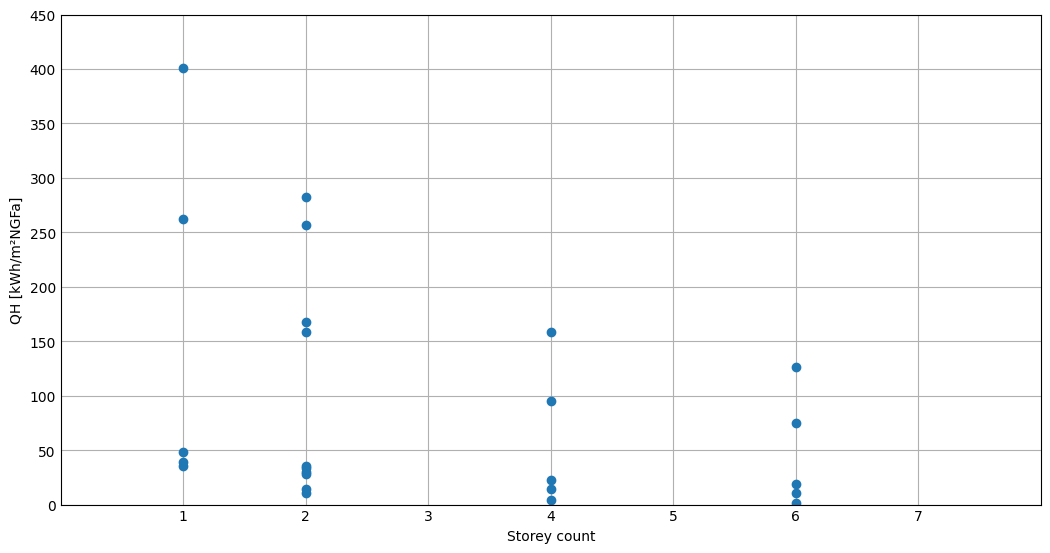

In [11]:
import matplotlib.pyplot as plt
import numpy as np

x = []
y = []

for variant in Variants:
    x.append(project[variant].scenarios[0].inn.storey_count_avg)
    y.append(project[variant].scenarios[0].out.QH)

plt.style.use("_mpl-gallery")


# plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(x, y)
ax.set_xlabel("Storey count")
ax.set_ylabel("QH [kWh/m²NGFa]")

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(1, 8), yticks=np.arange(0, 500, 50))

plt.show()


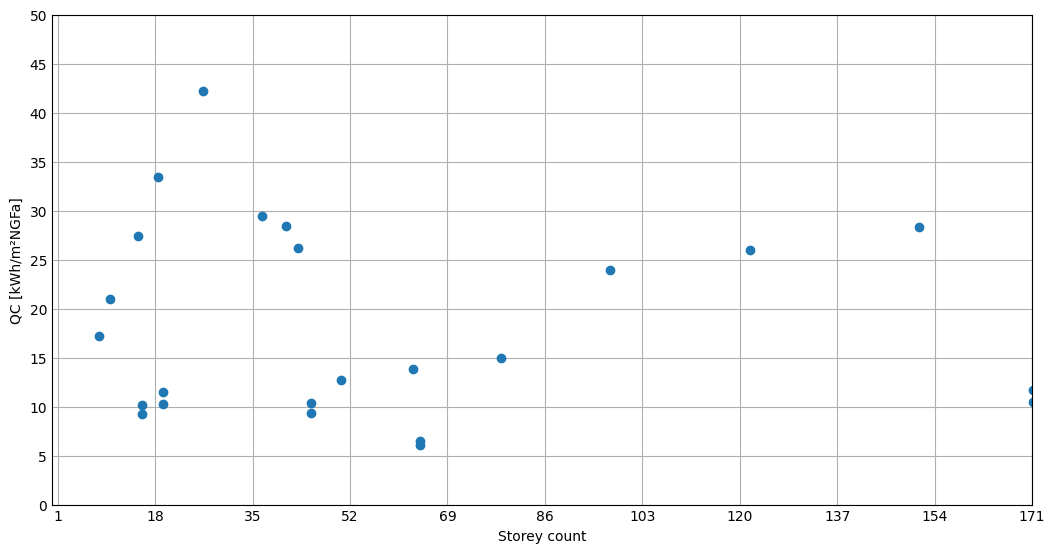

In [12]:
import matplotlib.pyplot as plt
import numpy as np

x = []
y = []

for variant in Variants:
    x.append(project[variant].scenarios[0].inn.hull_window_m2)
    y.append(project[variant].scenarios[0].out.QS)

plt.style.use("_mpl-gallery")

# plot
# Add figsize=(width, height) here. For example, 10 inches wide by 6 inches tall:
fig, ax = plt.subplots(figsize=(10, 5)) 

ax.scatter(x, y)
ax.set_xlabel("Storey count")
ax.set_ylabel("QC [kWh/m²NGFa]")

ax.set(xlim=(0, 8), xticks=np.arange(1, max(x), round(max(x)/10,0)),
       ylim=(1, 8), yticks=np.arange(0, max(y), round(max(y)/10,0)))

plt.show()

In [13]:
domains = project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].out.domains()
domains

['comfort',
 'cooling',
 'dhw',
 'electricity_dispatch',
 'electricity_end_use',
 'embodied_emissions',
 'energy_dispatch',
 'final_energy',
 'heat_balance',
 'heating',
 'mobility',
 'operational_emissions',
 'pe_import_export_balance',
 'primary_energy_balance',
 'useful_energy',
 'weather']

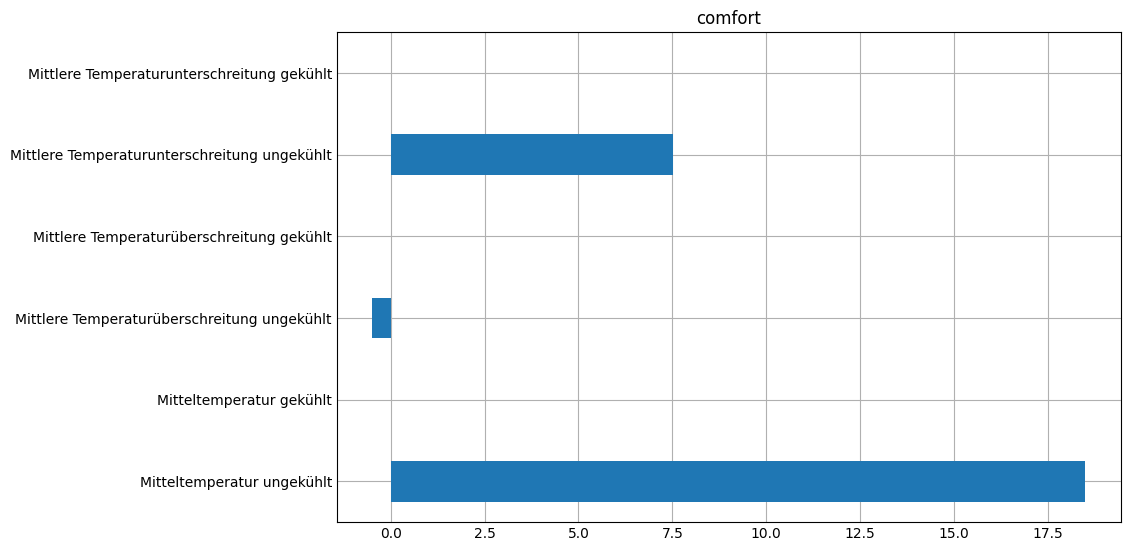

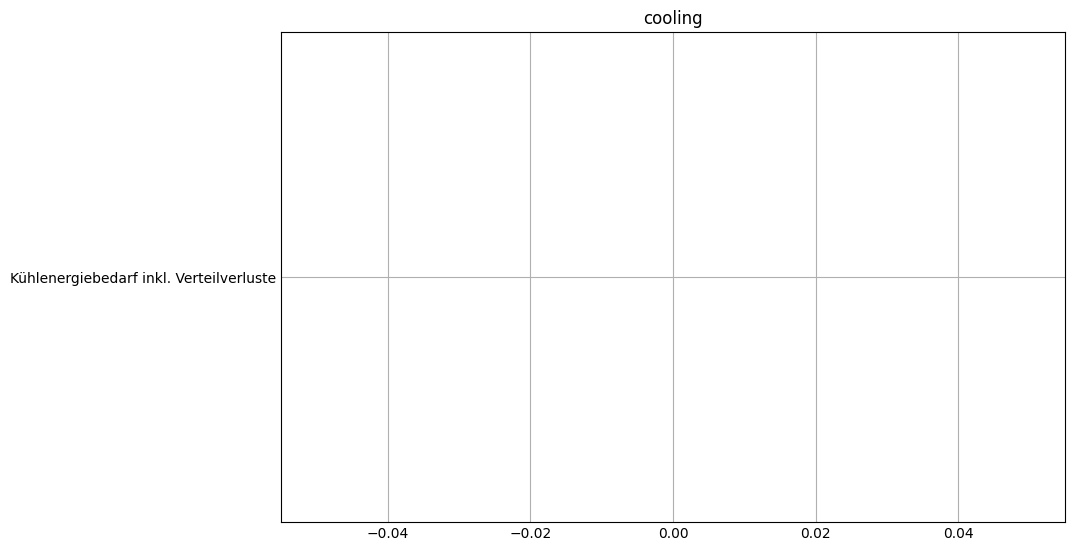

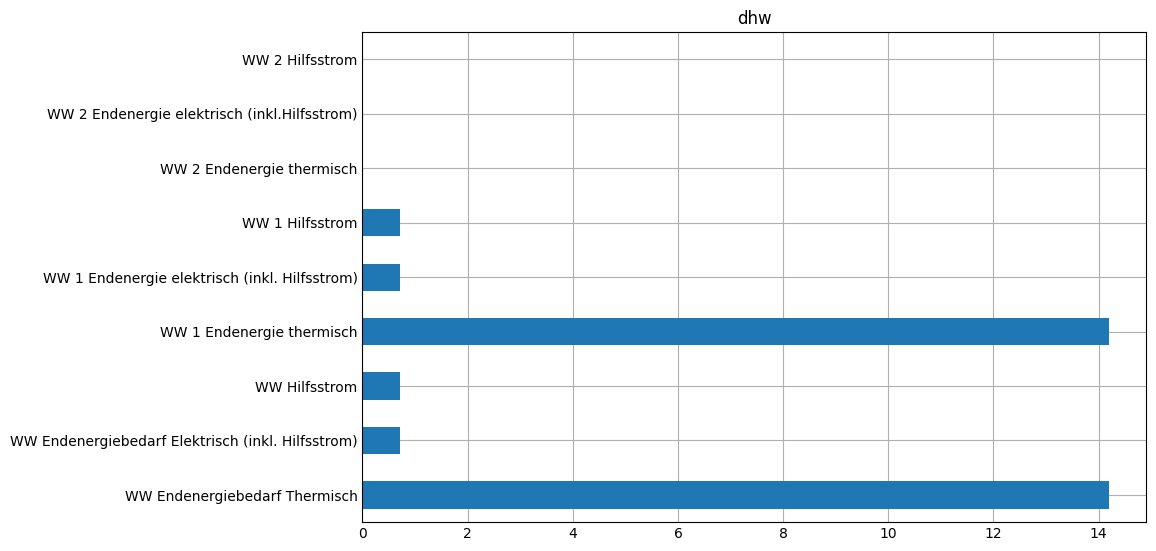

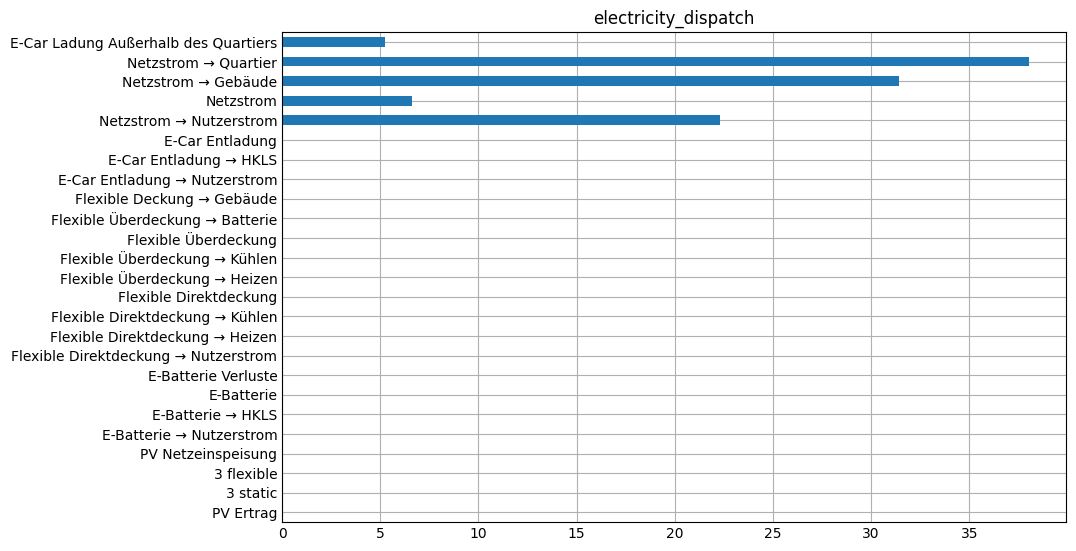

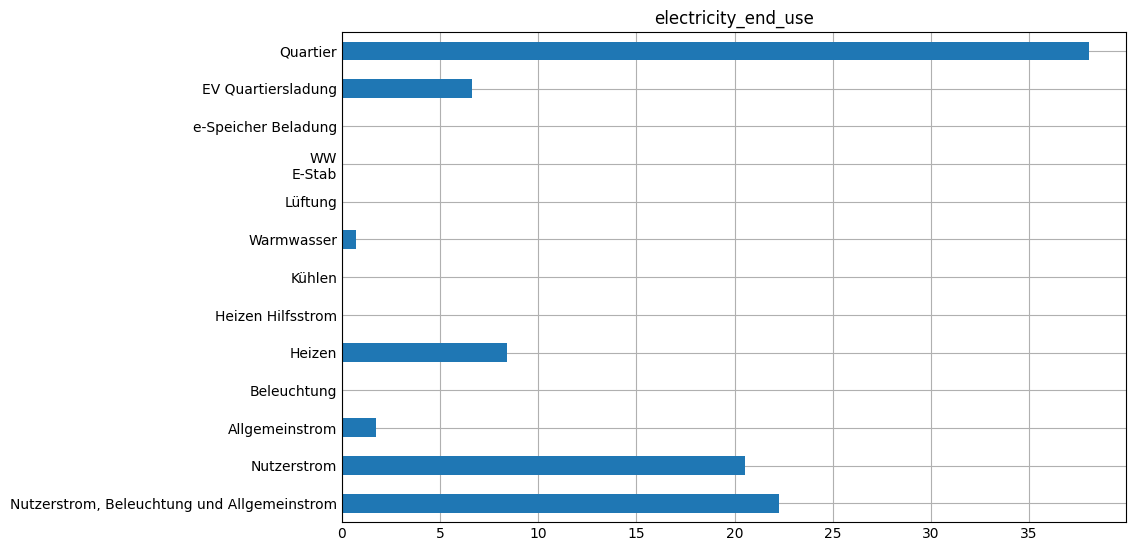

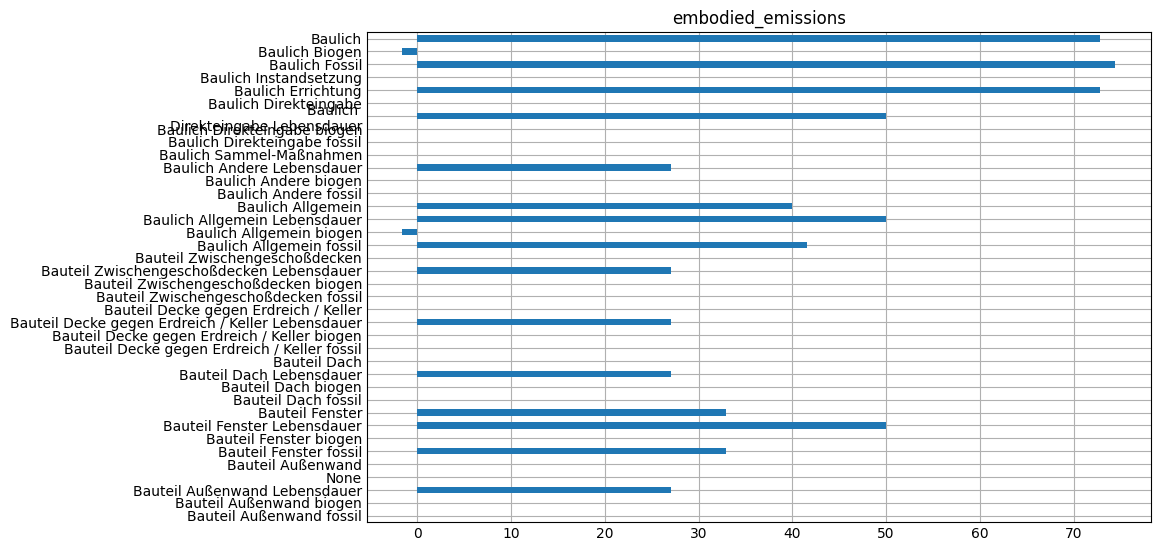

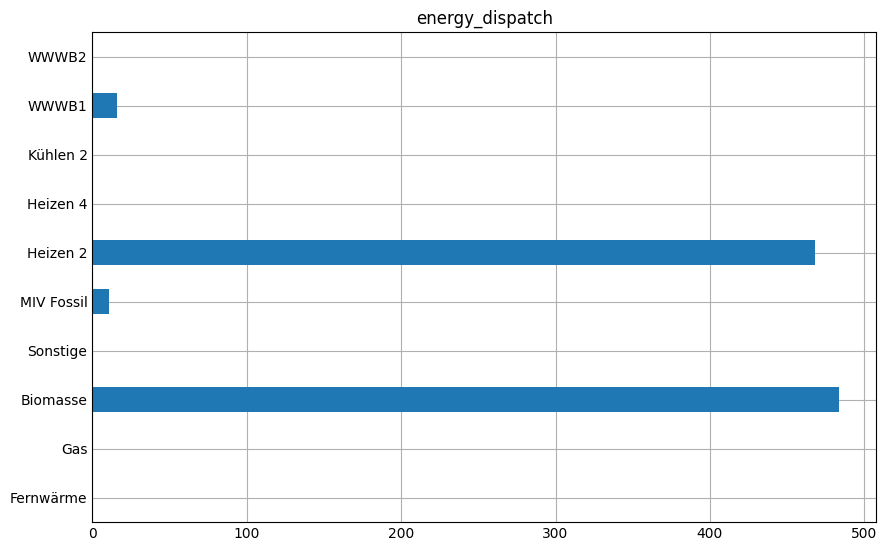

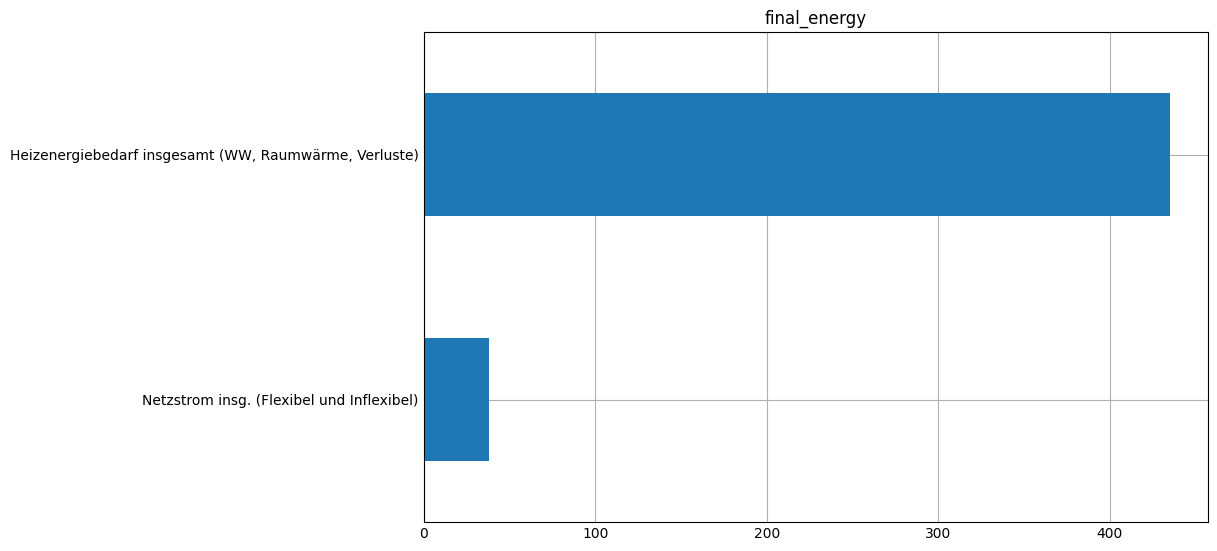

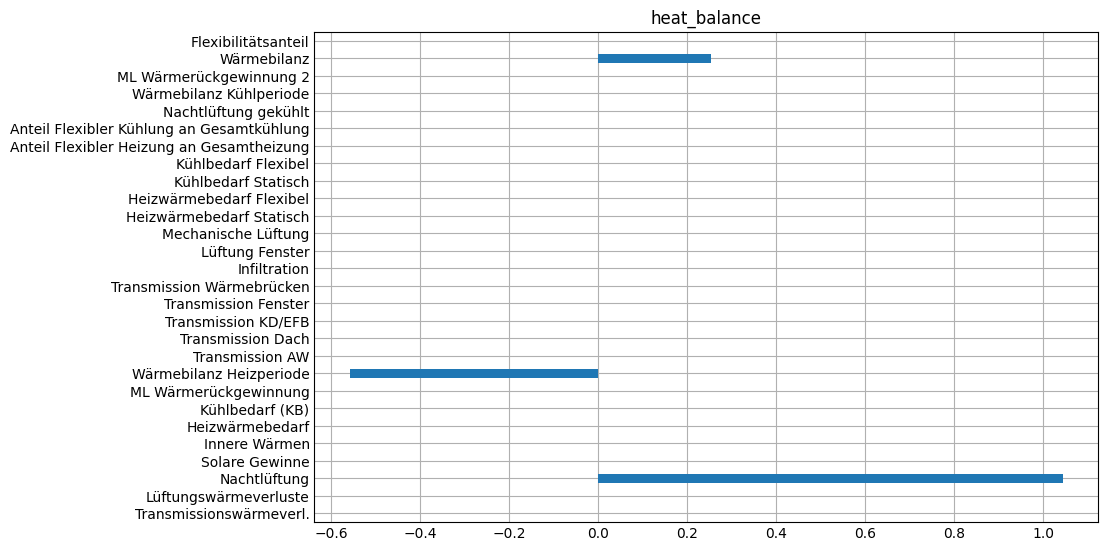

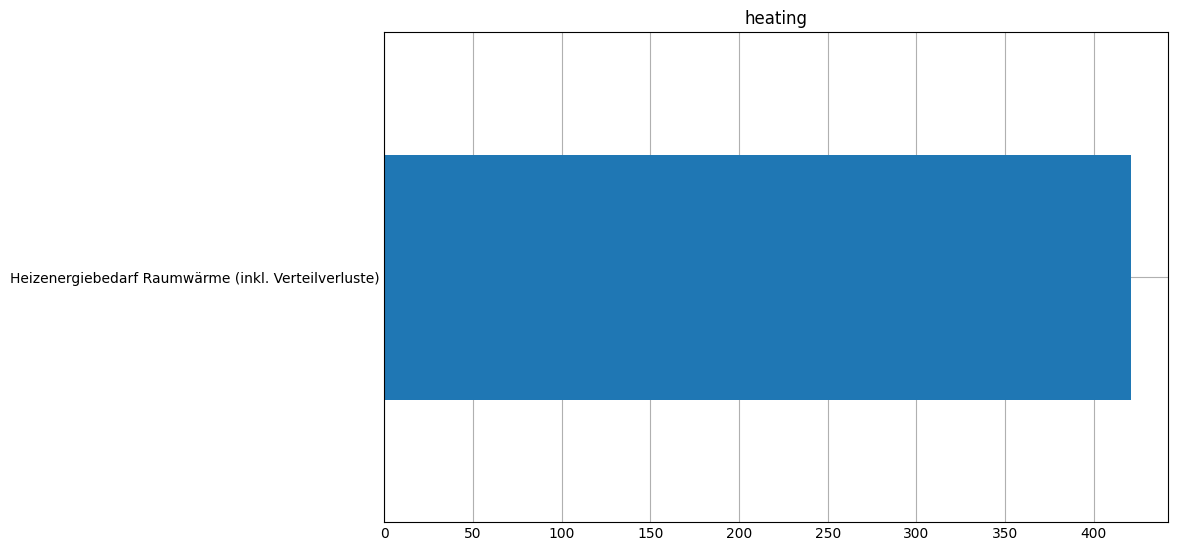

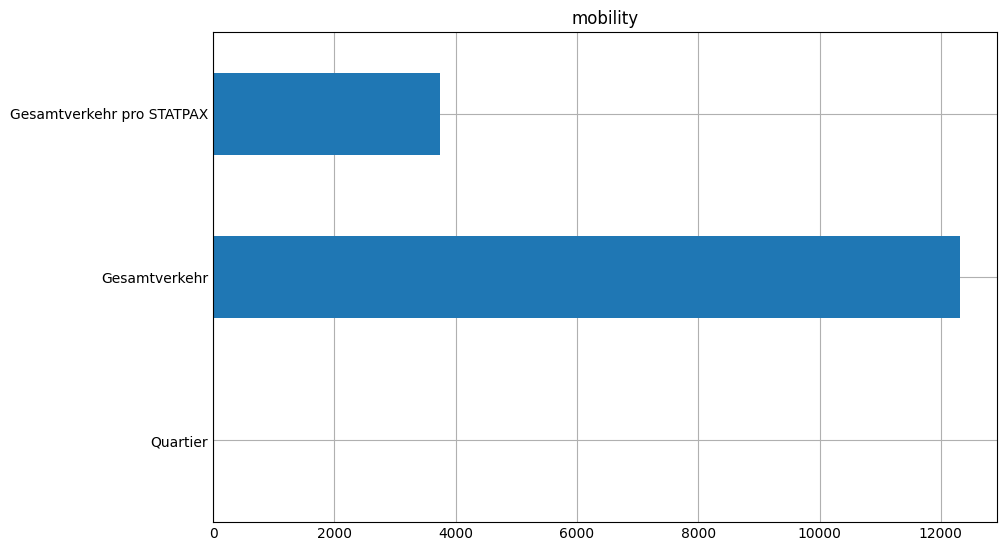

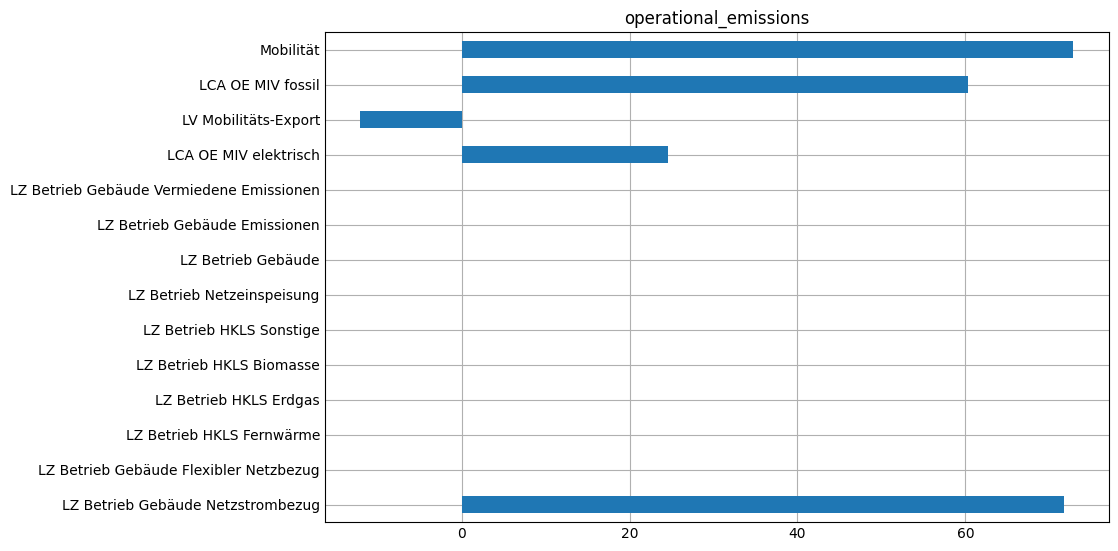

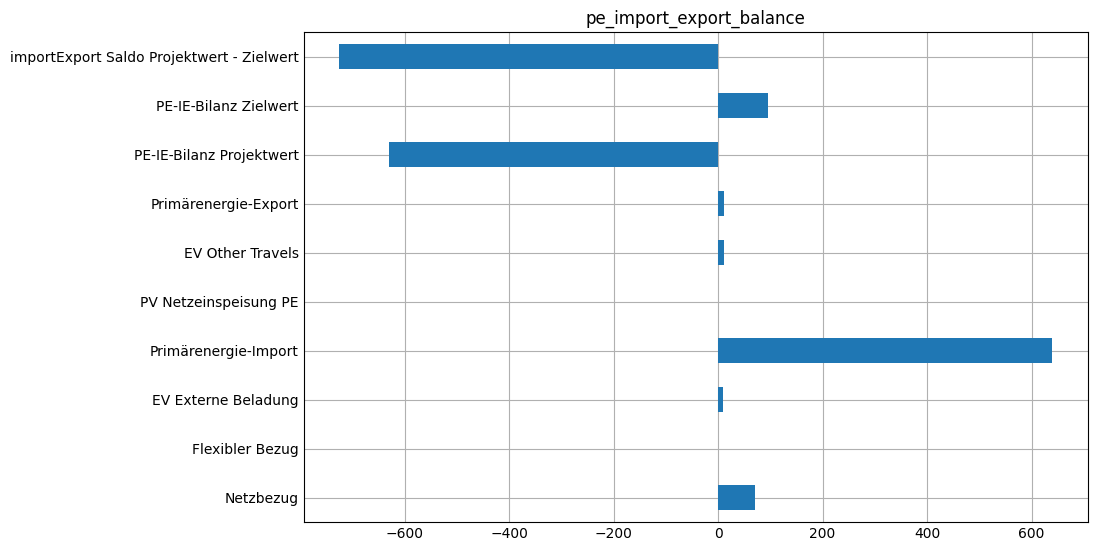

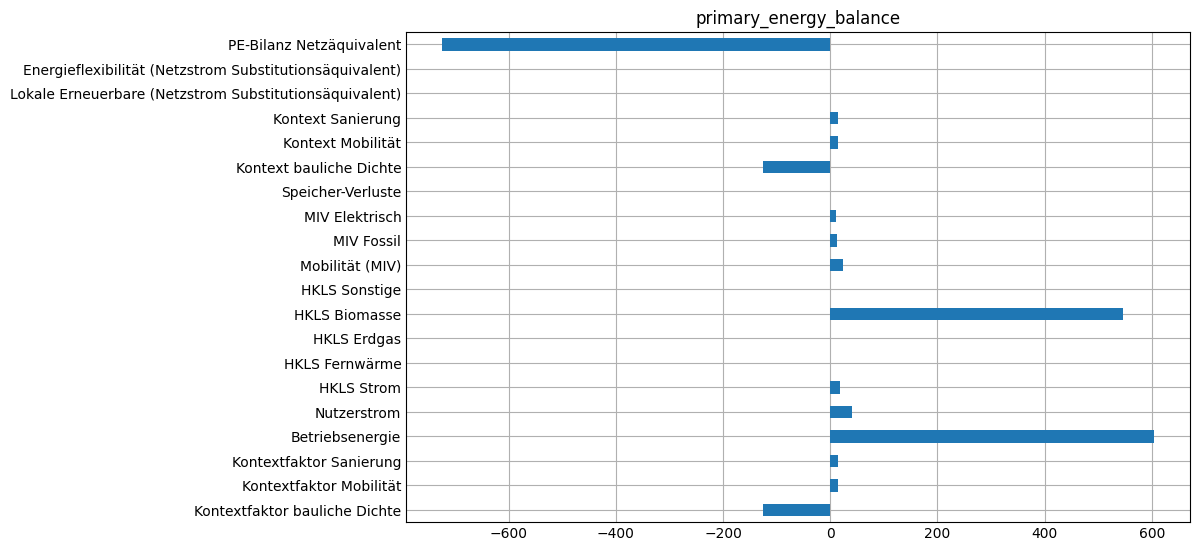

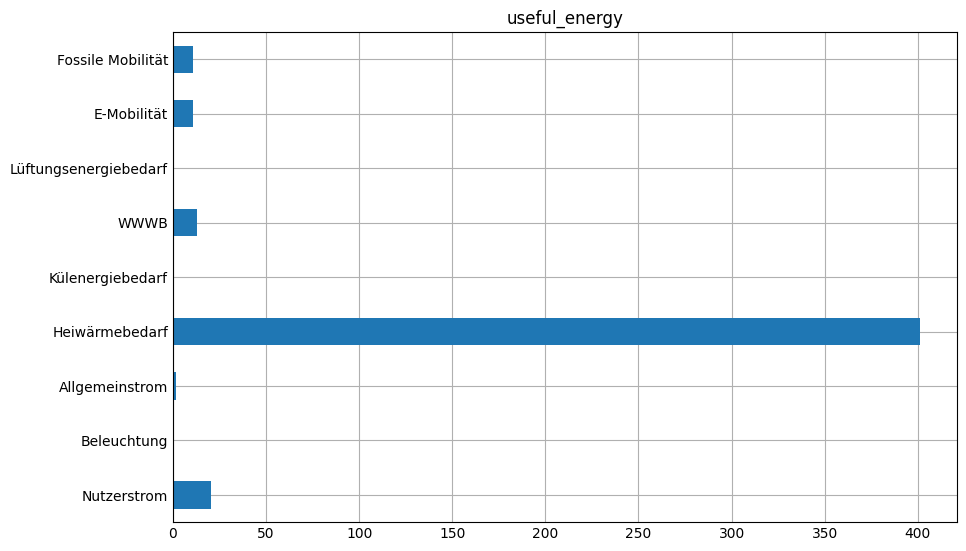

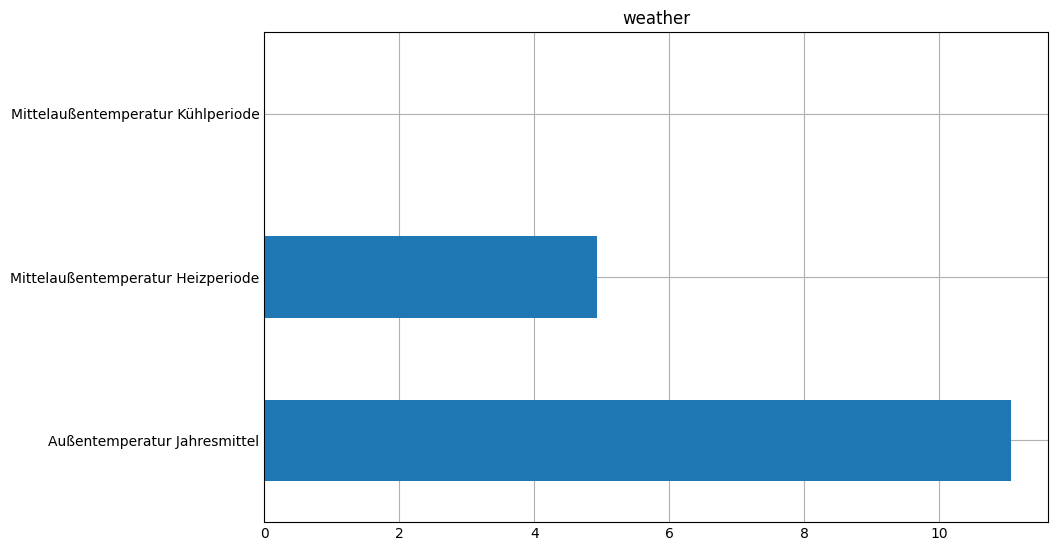

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

for domain in domains:
    chart_data = project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].out.by(domain=domain)
    diagram_components = {meta.label_de: value for meta, value in chart_data.items()}
    
    pd.Series(diagram_components).plot(kind="barh", figsize=(8,5), title=str(domain))
    
    plt.show()

In [15]:
chart_data = project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].out.by(domain="heat_balance")
chart_data.items_dict()

{<VarMeta 🧱 QT [kWh/m²NGFa] @OUT>: 420.0437813419044,
 <VarMeta 💨 QV [kWh/m²NGFa] @OUT>: 43.985800566136476,
 <VarMeta 🌒 QVn [kWh/m²NGFa] @OUT>: 1.0443484106614727,
 <VarMeta 🌞 QS [kWh/m²NGFa] @OUT>: 20.964055935398257,
 <VarMeta 👤 QI [kWh/m²NGFa] @OUT>: 42.83914161138317,
 <VarMeta ♨ QH [kWh/m²NGFa] @OUT>: 401.0162883375527,
 <VarMeta ❄ QC [kWh/m²NGFa] @OUT>: 0,
 <VarMeta QV_heatrecovery [kWh/m²NGFa] @OUT>: 0,
 <VarMeta QT_winter [kWh/m²NGFa] @OUT>: 383.6221127255263,
 <VarMeta QV_winter [kWh/m²NGFa] @OUT>: 40.17182611107401,
 <VarMeta QVn_winter [kWh/m²NGFa] @OUT>: 0,
 <VarMeta QS_winter [kWh/m²NGFa] @OUT>: 6.638519532838781,
 <VarMeta QI_winter [kWh/m²NGFa] @OUT>: 16.69586962797004,
 <VarMeta QH_winter [kWh/m²NGFa] @OUT>: 401.0162883375527,
 <VarMeta QC_winter [kWh/m²NGFa] @OUT>: 0,
 <VarMeta ☑ test_heat_balance_winter [False] @OUT>: -0.5567386617611874,
 <VarMeta QT_wall_winter [kWh/m²NGFa] @OUT>: 85.70745030990011,
 <VarMeta QT_roof_winter [kWh/m²NGFa] @OUT>: 186.38466173700678,
 

In [16]:
chart_data.to_var_dict()

{'QT': 420.0437813419044,
 'QV': 43.985800566136476,
 'QVn': 1.0443484106614727,
 'QS': 20.964055935398257,
 'QI': 42.83914161138317,
 'QH': 401.0162883375527,
 'QC': 0,
 'QV_heatrecovery': 0,
 'QT_winter': 383.6221127255263,
 'QV_winter': 40.17182611107401,
 'QVn_winter': 0,
 'QS_winter': 6.638519532838781,
 'QI_winter': 16.69586962797004,
 'QH_winter': 401.0162883375527,
 'QC_winter': 0,
 'test_heat_balance_winter': -0.5567386617611874,
 'QT_wall_winter': 85.70745030990011,
 'QT_roof_winter': 186.38466173700678,
 'QT_ground_winter': 69.82458280365438,
 'QT_window_winter': 6.830680354462633,
 'QT_psi_winter': 34.87473752050239,
 'QV_inf_winter': 25.824745357119028,
 'QV_window_winter': 14.34708075395498,
 'QV_mechvent_winter': 0,
 'QV_heatrecovery_winter': 0,
 'QH_min_winter': 401.0162883375527,
 'QH_flex_winter': 0,
 'QC_min_winter': 0,
 'QC_flex_winter': 0,
 'QH_flexshare_winter': 0,
 'QC_flexshare_winter': 0,
 'QT_summer': 0,
 'QV_summer': 0,
 'QVn_summer': 0,
 'QS_summer': 0,
 'QI

In [17]:
project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].out.by(domain="heat_balance").to_var_dict()

{'QT': 420.0437813419044,
 'QV': 43.985800566136476,
 'QVn': 1.0443484106614727,
 'QS': 20.964055935398257,
 'QI': 42.83914161138317,
 'QH': 401.0162883375527,
 'QC': 0,
 'QV_heatrecovery': 0,
 'QT_winter': 383.6221127255263,
 'QV_winter': 40.17182611107401,
 'QVn_winter': 0,
 'QS_winter': 6.638519532838781,
 'QI_winter': 16.69586962797004,
 'QH_winter': 401.0162883375527,
 'QC_winter': 0,
 'test_heat_balance_winter': -0.5567386617611874,
 'QT_wall_winter': 85.70745030990011,
 'QT_roof_winter': 186.38466173700678,
 'QT_ground_winter': 69.82458280365438,
 'QT_window_winter': 6.830680354462633,
 'QT_psi_winter': 34.87473752050239,
 'QV_inf_winter': 25.824745357119028,
 'QV_window_winter': 14.34708075395498,
 'QV_mechvent_winter': 0,
 'QV_heatrecovery_winter': 0,
 'QH_min_winter': 401.0162883375527,
 'QH_flex_winter': 0,
 'QC_min_winter': 0,
 'QC_flex_winter': 0,
 'QH_flexshare_winter': 0,
 'QC_flexshare_winter': 0,
 'QT_summer': 0,
 'QV_summer': 0,
 'QVn_summer': 0,
 'QS_summer': 0,
 'QI

# Wärmebilanz

9


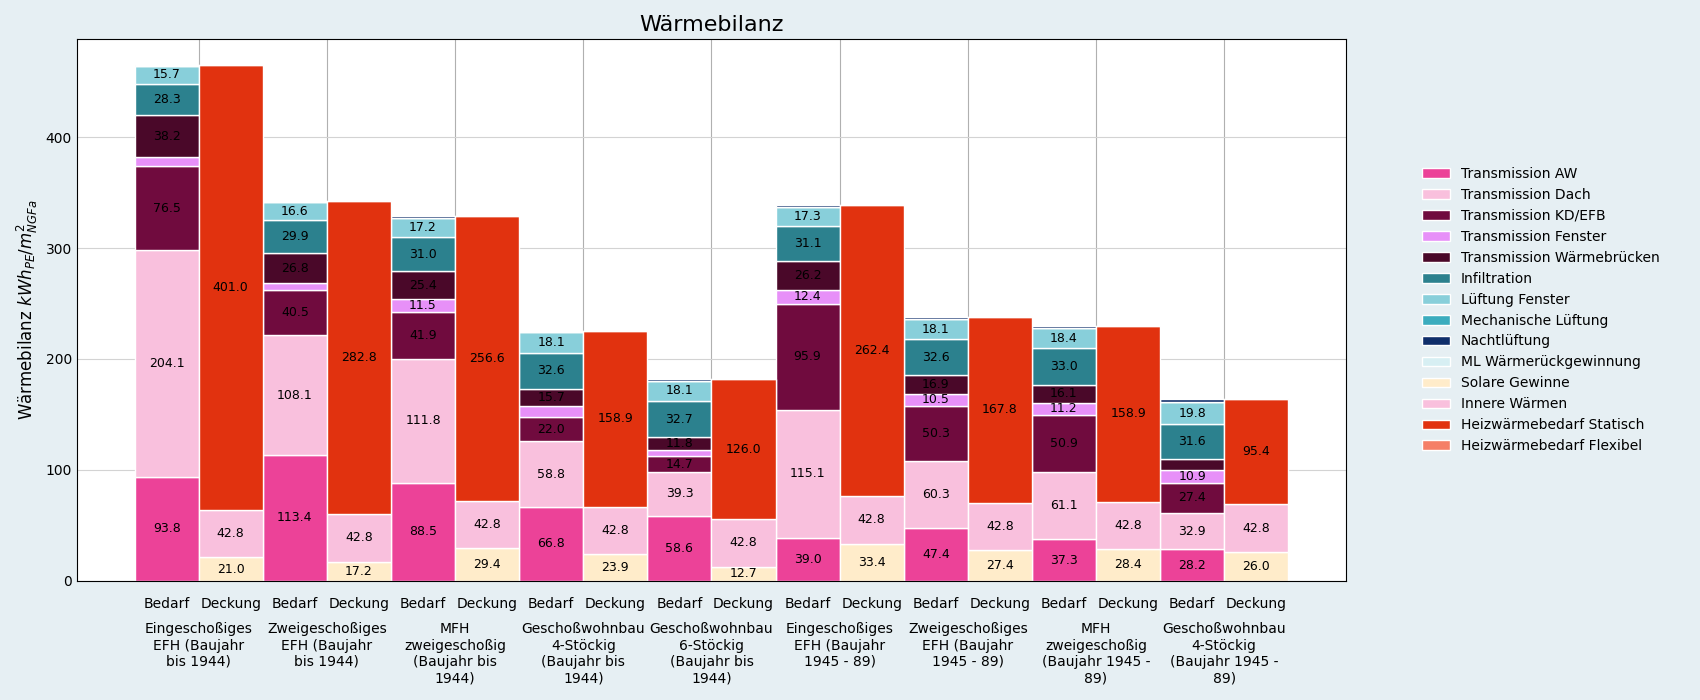

In [71]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import textwrap
import mplcursors

plt.close('all') # Clears previous interactive runs

# 1. Simulate your varnames/scenarios (You likely have a list of these in your real code)
title = "Wärmebilanz"
variants_to_display = Variants[:9]
varnames = []
extracted_data = []

for variant in variants_to_display:
    varnames.append(variant)
    extracted_data.append(project[variant].scenarios[0].out.by(domain="heat_balance").to_var_dict())
print(len(extracted_data))
# 2. Define the Mapping (Which variables go into which stack)
bedarf_mapping = {
    "Transmission AW": ("QT_wall_u", "#ec4298"),
    "Transmission Dach": ("QT_roof_u", "#f9c0dd"),
    "Transmission KD/EFB": ("QT_ground_u", "#700b3e"),
    "Transmission Fenster": ("QT_window_u", "#e790f8"),
    "Transmission Wärmebrücken": ("QT_psi_u", "#4a0829"),
    "Infiltration": ("QV_inf_u", "#2c818e"),
    "Lüftung Fenster": ("QV_window_u", "#88cfda"),
    "Mechanische Lüftung": ("QV_mechvent_u", "#3bacbe"),
    "Nachtlüftung": ("QVn_u", "#0f2e6a"),
}

deckung_mapping = {
    "ML Wärmerückgewinnung": ("QV_heatrecovery_u", "#d7eff3"),
    "Solare Gewinne": ("QS_u", "#ffecca"),
    "Innere Wärmen": ("QI_u", "#f9c0dd"),
    "Heizwärmebedarf Statisch": ("QH_min_u", "#e1320f"),
    "Heizwärmebedarf Flexibel": ("QH_flex_u", "#f57f67")
}

# 4. Setup the Plot
max_chars = 15 # Choose how many characters wide you want the text to be before it breaks to a new line
wrapped_labels = [textwrap.fill(label, width=max_chars) for label in varnames]
x = np.arange(len(varnames)) 
width = 0.5
fig, ax = plt.subplots(num = title, figsize=(len(extracted_data)+8, 7))

all_bars = []

# 5. Plot "Bedarf" (Left bars)
bottom_bedarf = np.zeros(len(varnames))
for label_de, (dict_key, color) in bedarf_mapping.items():
    # Extract the value for this specific key across all varnames
    # (Note: In your real code, you might need to match dict_key to meta.name)
    values = [data.get(dict_key, 0) for data in extracted_data]
    
    bars = ax.bar(x - width/2, values, width, label=label_de, bottom=bottom_bedarf, color=color, edgecolor="white")
    all_bars.append(bars)
    # Data labels
    for bar in bars:
        height = bar.get_height()
        if height > 10:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f"{height:.1f}", ha="center", va="center", color="black", fontsize=9)
            
    bottom_bedarf += np.array(values)

# 6. Plot "Deckung" (Right bars)
bottom_deckung = np.zeros(len(varnames))
for label_de, (dict_key, color) in deckung_mapping.items():
    values = [data.get(dict_key, 0) for data in extracted_data]
    
    bars = ax.bar(x + width/2, values, width, label=label_de, bottom=bottom_deckung, color=color, edgecolor="white")
    all_bars.append(bars)
    # Data labels
    for bar in bars:
        height = bar.get_height()
        if height > 10:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f"{height:.1f}", ha="center", va="center", color="black", fontsize=9)
            
    bottom_deckung += np.array(values)

# 7. Add Sub-labels and Formatting
for i in range(len(varnames)):
    ax.text(i - width/2, -15, "Bedarf", ha="center", va="top", fontsize=10)
    ax.text(i + width/2, -15, "Deckung", ha="center", va="top", fontsize=10)

ax.set_ylabel("Wärmebilanz $kWh_{PE}/m^2_{NGFa}$", fontsize = 12)
ax.set_xticks(x)
ax.set_xticklabels(wrapped_labels)
ax.tick_params(axis="x", pad=30) 
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgray", linestyle="-")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), frameon=False)
fig.patch.set_facecolor('#e6eff3')
ax.set_title(title, fontsize = 16)

cursor = mplcursors.cursor(all_bars, hover=True)

@cursor.connect("add")
def on_add(sel):
    # 1. Get the category label (e.g., "Fernwärme" or "Heizen")
    category_label = sel.artist.get_label()
    
    # 2. Get the specific rectangle object you are hovering over
    rect = sel.artist[sel.index]
    
    # 3. Get the height (value) of that specific rectangle
    height = rect.get_height()
    
    # 4. Get the x-axis scenario name (using sel.index to map back to varnames)
    variant_name = varnames[sel.index]
    
    # Set the tooltip text dynamically
    sel.annotation.set_text(f"{category_label}: {height:.1f}")
    
    # Style the tooltip box
    sel.annotation.get_bbox_patch().set(alpha=0.9, color='white', edgecolor='gray')

plt.tight_layout()
plt.show()

# Primärenergiebedarf

9


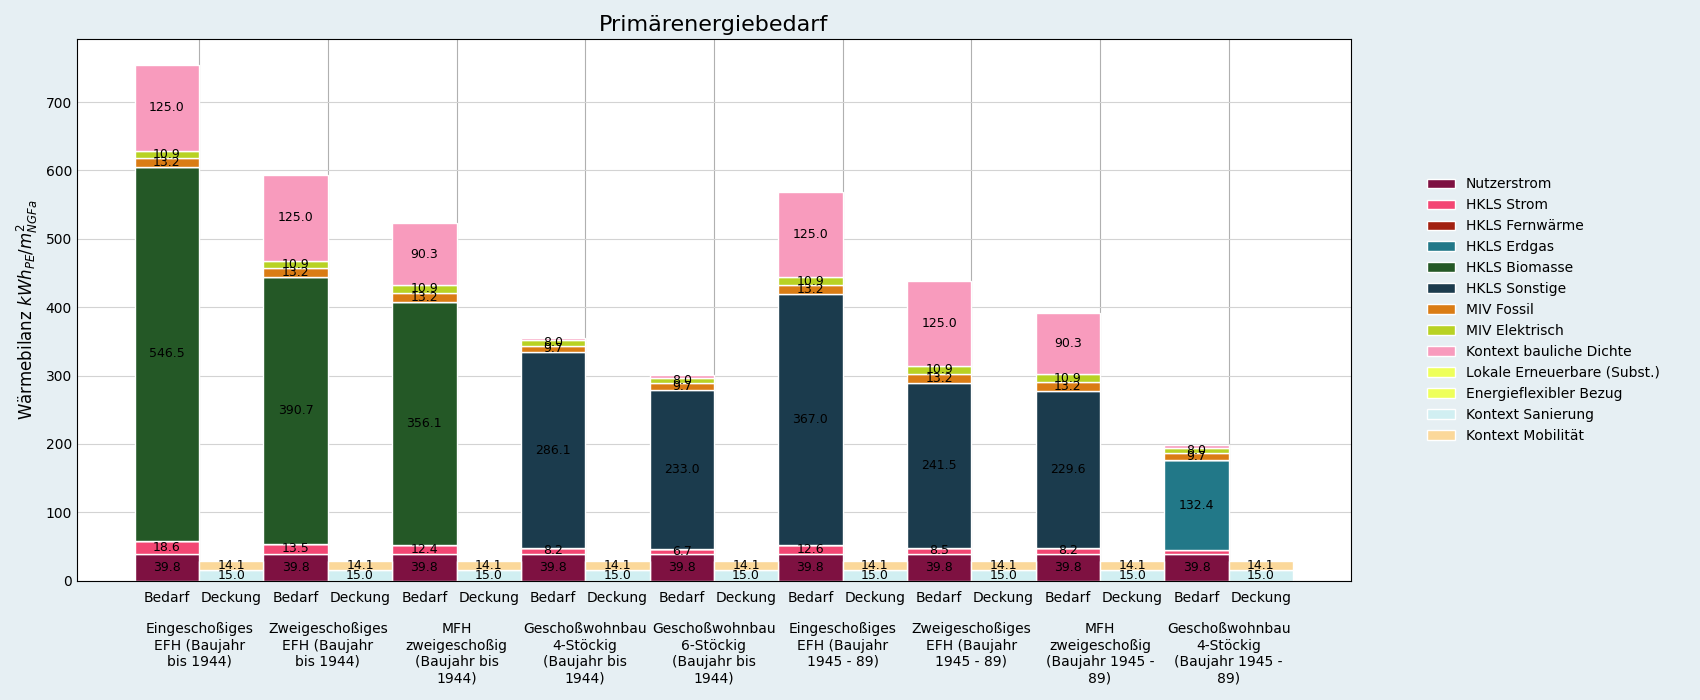

In [70]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import textwrap
import mplcursors

plt.close('all') # Clears previous interactive runs

# 1. Simulate your varnames/scenarios (You likely have a list of these in your real code)
title = "Primärenergiebedarf"
variants_to_display = Variants[:9]
varnames = []
extracted_data = []

for variant in variants_to_display:
    varnames.append(variant)
    extracted_data.append(project[variant].scenarios[0].out.by(domain="primary_energy_balance").to_var_dict())
print(len(extracted_data))
# 2. Define the Mapping (Which variables go into which stack)
bedarf_mapping = {
    "Nutzerstrom": ("PEI_el_plugloads", "#7e1141"),
    "HKLS Strom": ("PEI_el_hvac", "#f34673"),
    "HKLS Fernwärme": ("PEI_district_heating", "#a22110"),
    "HKLS Erdgas": ("PEI_natural_gas", "#227888"),
    "HKLS Biomasse": ("PEI_biomass", "#245826"),
    "HKLS Sonstige": ("PEI_other", "#1b3b4d"),
    "MIV Fossil": ("PEI_mob_fossile", "#da7c14"),
    "MIV Elektrisch": ("PEI_mob_el", "#b8d223")
}

deckung_mapping = {
    "Lokale Erneuerbare (Subst.)": ("PEI_sub_PV","#eeff5b"),
    "Energieflexibler Bezug": ("PEI_sub_flex", "#eeff5b"),
    "Kontext Sanierung": ("PEI_cf_renovation", "#d1eff2"),
    "Kontext Mobilität": ("PEI_cf_mobility", "#fbd89a")   
}

# Wenn PEI_cf_density < 0 dann Bedarf
## Um negative Werte zu vermeiden wird später für alle Werte der Betrag genommen.
for i, varname in enumerate(variants_to_display):
    if extracted_data[i]["PEI_cf_density"] < 0:
        bedarf_mapping["Kontext bauliche Dichte"] = ("PEI_cf_density", "#f89bbd")
    elif extracted_data[i]["PEI_cf_density"] > 0:
        deckung_mapping["Kontext bauliche Dichte"] = ("PEI_cf_density", "#f89bbd")
    else: print("Unbekannter Fehler mit Variable PEI_cf_density")

# 4. Setup the Plot
max_chars = 15 # Choose how many characters wide you want the text to be before it breaks to a new line
wrapped_labels = [textwrap.fill(label, width=max_chars) for label in varnames]
x = np.arange(len(varnames)) 
width = 0.5
fig, ax = plt.subplots(num = title, figsize=(len(extracted_data)+8, 7))

all_bars = []

# 5. Plot "Bedarf" (Left bars)
bottom_bedarf = np.zeros(len(varnames))
for label_de, (dict_key, color) in bedarf_mapping.items():
    # Extract the value for this specific key across all varnames
    # (Note: In your real code, you might need to match dict_key to meta.name)
    values = [abs(data.get(dict_key, 0))for data in extracted_data]
    
    bars = ax.bar(x - width/2, values, width, label=label_de, bottom=bottom_bedarf, color=color, edgecolor="white")
    all_bars.append(bars)
    # Data labels
    for bar in bars:
        height = bar.get_height()
        if height > 6:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f"{height:.1f}", ha="center", va="center", color="black", fontsize=9)
            
    bottom_bedarf += np.array(values)

# 6. Plot "Deckung" (Right bars)
bottom_deckung = np.zeros(len(varnames))
for label_de, (dict_key, color) in deckung_mapping.items():
    values = [abs(data.get(dict_key, 0)) for data in extracted_data]
    
    bars = ax.bar(x + width/2, values, width, label=label_de, bottom=bottom_deckung, color=color, edgecolor="white")
    all_bars.append(bars)
    # Data labels
    for bar in bars:
        height = bar.get_height()
        if height > 6:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f"{height:.1f}", ha="center", va="center", color="black", fontsize=9)
            
    bottom_deckung += np.array(values)

# 7. Add Sub-labels and Formatting
for i in range(len(varnames)):
    ax.text(i - width/2, -15, "Bedarf", ha="center", va="top", fontsize=10)
    ax.text(i + width/2, -15, "Deckung", ha="center", va="top", fontsize=10)

ax.set_ylabel("Wärmebilanz $kWh_{PE}/m^2_{NGFa}$", fontsize = 12)
ax.set_xticks(x)
ax.set_xticklabels(wrapped_labels)
ax.tick_params(axis="x", pad=30) 
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgray", linestyle="-")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), frameon=False)
fig.patch.set_facecolor('#e6eff3')
ax.set_title(title, fontsize = 16)


cursor = mplcursors.cursor(all_bars, hover=True)

@cursor.connect("add")
def on_add(sel):
    # 1. Get the category label (e.g., "Fernwärme" or "Heizen")
    category_label = sel.artist.get_label()
    
    # 2. Get the specific rectangle object you are hovering over
    rect = sel.artist[sel.index]
    
    # 3. Get the height (value) of that specific rectangle
    height = rect.get_height()
    
    # 4. Get the x-axis scenario name (using sel.index to map back to varnames)
    variant_name = varnames[sel.index]
    
    # Set the tooltip text dynamically
    sel.annotation.set_text(f"{category_label}: {height:.1f}")
    
    # Style the tooltip box
    sel.annotation.get_bbox_patch().set(alpha=0.9, color='white', edgecolor='gray')

plt.tight_layout()
plt.show()

In [20]:
project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].out.by(domain="primary_energy_balance").to_var_dict()

{'context_factor_density': -125,
 'context_factor_mobility': 14.107740396658576,
 'context_factor_renovation': 15,
 'PEI_demand': 604.9237963944711,
 'PEI_el_plugloads': 39.785566227928854,
 'PEI_el_hvac': 18.635501452416232,
 'PEI_district_heating': 0,
 'PEI_natural_gas': 0,
 'PEI_biomass': 546.502728714126,
 'PEI_other': 0,
 'PEI_mob_total': 24.037919656842373,
 'PEI_mob_fossile': 13.182145381294966,
 'PEI_mob_el': 10.855774275547407,
 'PEI_storage_losses': 0,
 'PEI_cf_density': -125,
 'PEI_cf_mobility': 14.107740396658576,
 'PEI_cf_renovation': 15,
 'PEI_sub_PV': 0,
 'PEI_sub_flex': 0,
 'PEI_balance': -724.853975654655}

In [21]:
extracted_data

[{'context_factor_density': -125,
  'context_factor_mobility': 14.107740396658576,
  'context_factor_renovation': 15,
  'PEI_demand': 604.9237963944711,
  'PEI_el_plugloads': 39.785566227928854,
  'PEI_el_hvac': 18.635501452416232,
  'PEI_district_heating': 0,
  'PEI_natural_gas': 0,
  'PEI_biomass': 546.502728714126,
  'PEI_other': 0,
  'PEI_mob_total': 24.037919656842373,
  'PEI_mob_fossile': 13.182145381294966,
  'PEI_mob_el': 10.855774275547407,
  'PEI_storage_losses': 0,
  'PEI_cf_density': -125,
  'PEI_cf_mobility': 14.107740396658576,
  'PEI_cf_renovation': 15,
  'PEI_sub_PV': 0,
  'PEI_sub_flex': 0,
  'PEI_balance': -724.853975654655},
 {'context_factor_density': -125,
  'context_factor_mobility': 14.107740396658576,
  'context_factor_renovation': 15,
  'PEI_demand': 443.98734686243705,
  'PEI_el_plugloads': 39.785566227928854,
  'PEI_el_hvac': 13.518937792517665,
  'PEI_district_heating': 0,
  'PEI_natural_gas': 0,
  'PEI_biomass': 390.6828428419905,
  'PEI_other': 0,
  'PEI_m

In [22]:
for i, j in enumerate(domains):
    print(i, j)

0 comfort
1 cooling
2 dhw
3 electricity_dispatch
4 electricity_end_use
5 embodied_emissions
6 energy_dispatch
7 final_energy
8 heat_balance
9 heating
10 mobility
11 operational_emissions
12 pe_import_export_balance
13 primary_energy_balance
14 useful_energy
15 weather


In [23]:
final_energy_params = {}
final_energy_params.update(project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].out.by(domain=domains[3]).to_var_dict())
final_energy_params.update(project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].out.by(domain=domains[4]).to_var_dict())
final_energy_params.update(project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].out.by(domain=domains[6]).to_var_dict())
final_energy_params.update(project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].out.by(domain=domains[7]).to_var_dict())
final_energy_params

{'PV_total': 0,
 'PV_to_plugloads': 0,
 'PV_to_Eh_min': 0,
 'PV_to_Ec_min': 0,
 'PV_to_Edhw_min': 0,
 'PV_to_Ev_min': 0,
 'PV_to_Eev_min': 0,
 'PV_total_direct': 0,
 'PV_to_Eh_flex': 0,
 'PV_to_Ec_flex': 0,
 'PV_to_Edhw': 0,
 'PV_to_Edhw_direct': 0,
 'PV_to_Batt': 0,
 'PV_to_Eev_flex': 0,
 'PV_total_flex': 0,
 'PV_to_Egrid': 0,
 'Batt_to_plugloads': 0,
 'Batt_to_HVAC': 0,
 'Batt_to_Eh_min': 0,
 'Batt_to_Ec_min': 0,
 'Batt_to_Edhw_min': 0,
 'Batt_to_Ev_min': 0,
 'Batt_to_Eev_min': 0,
 'Batt_charging_losses': 0,
 'VRGrid_to_plugloads': 0,
 'VRGrid_to_Eh_min': 0,
 'VRGrid_to_Ec_min': 0,
 'VRGrid_to_Edhw_min': 0,
 'VRGrid_to_Ev_min': 0,
 'VRGrid_to_Eev_min': 0,
 'VRGrid_to_min': 0,
 'VRGrid_to_Eh_flex': 0,
 'VRGrid_to_Ec_flex': 0,
 'VRGrid_to_Edhw_flex': 0,
 'VRGrid_to_Batt': 0,
 'VRGrid_to_Eev_flex': 0,
 'VRGrid_to_flex': 0,
 'VRGrid_to_building': 0,
 'Eev_to_plugloads': 0,
 'Eev_to_HVAC': 0,
 'Eev_to_Eh_min': 0,
 'Eev_to_Ec_min': 0,
 'Eev_to_Edhw_min': 0,
 'Eev_to_Ev_min': 0,
 'Eev_disch

# Endenergie

9


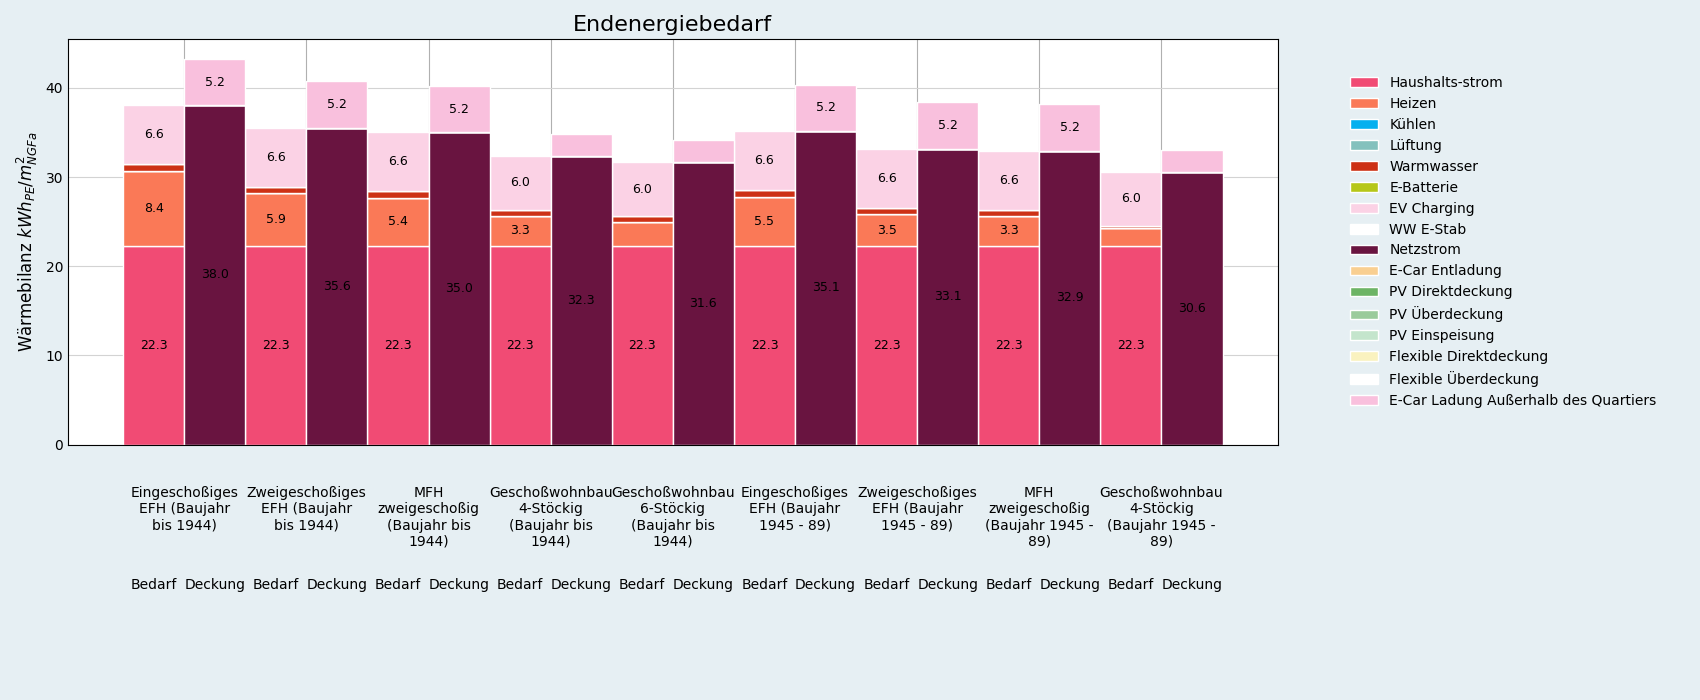

In [69]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import textwrap
import mplcursors

plt.close('all') # Clears previous interactive runs

# 1. Simulate your varnames/scenarios (You likely have a list of these in your real code)
title = "Endenergiebedarf"
variants_to_display = Variants[:9]
varnames = []
extracted_data = []

for variant in variants_to_display:
    varnames.append(variant)
    final_energy_params = {}
    final_energy_params.update(project[variant].scenarios[0].out.by(domain=domains[3]).to_var_dict())
    final_energy_params.update(project[variant].scenarios[0].out.by(domain=domains[4]).to_var_dict())
    final_energy_params.update(project[variant].scenarios[0].out.by(domain=domains[6]).to_var_dict())
    final_energy_params.update(project[variant].scenarios[0].out.by(domain=domains[7]).to_var_dict())
    extracted_data.append(final_energy_params)
print(len(extracted_data))
# 2. Define the Mapping (Which variables go into which stack)
bedarf_mapping = {
    "Haushalts-strom": ("EUI_plugAuxLight", "#f14b74"),
    "Heizen": ("EUIh_el", "#fa7957"),
    "Kühlen": ("EUIc_el", "#05b0ef"),
    "Lüftung": ("EUIv_el", "#84c1bd"),
    "Warmwasser": ("EUIdhw_el", "#cd3115"),
    "E-Batterie": ("Batt_total_charge_input", "#b6c718"),
    "EV Charging": ("EUIev_el", "#fbd2e5")
    #"e-Speicher Beladung": ("", "#ec3e88"),
}

deckung_mapping = {
    "WW E-Stab": ("EUIdhwdirect_el", "#ffffff"),
    "Netzstrom": ("Grid_to_min", "#691440"),
    "E-Car Entladung": ("Eev_to_district", "#f9cf91"),
    "PV Direktdeckung": ("PV_total_direct", "#6db465"),
    "PV Überdeckung": ("PV_total_flex", "#9bcb9b"),
    "PV Einspeisung": ("PV_to_Egrid", "#c4e5cc"),
    "Flexible Direktdeckung": ("VRGrid_to_min", "#faf2bf"),
    "Flexible Überdeckung": ("VRGrid_to_flex", "#ffffff"),
    "E-Car Ladung Außerhalb des Quartiers": ("Eev_ext_charge", "#f9c0dd"),
    #"Fernwärme": ("EUI_district_heating", "#aa3819"),
    #"Gas": ("EUI_natural_gas", "#1a7886"),
    #"Biomasse": ("EUI_biomass", "#2d623d"),
    #"Sonstige": ("EUI_other", "#1c4656")
}

# 4. Setup the Plot
max_chars = 15 # Choose how many characters wide you want the text to be before it breaks to a new line
wrapped_labels = [textwrap.fill(label, width=max_chars) for label in varnames]
x = np.arange(len(varnames)) 
width = 0.5
fig, ax = plt.subplots(num = title, figsize=(len(extracted_data)+8, 7))

all_bars = []

# 5. Plot "Bedarf" (Left bars)
bottom_bedarf = np.zeros(len(varnames))
for label_de, (dict_key, color) in bedarf_mapping.items():
    # Extract the value for this specific key across all varnames
    # (Note: In your real code, you might need to match dict_key to meta.name)
    values = [data.get(dict_key, 0) for data in extracted_data]
    
    bars = ax.bar(x - width/2, values, width, label=label_de, bottom=bottom_bedarf, color=color, edgecolor="white")
    all_bars.append(bars)
    
    # Data labels
    for bar in bars:
        height = bar.get_height()
        if height > 3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f"{height:.1f}", ha="center", va="center", color="black", fontsize=9)
            
    bottom_bedarf += np.array(values)

# 6. Plot "Deckung" (Right bars)
bottom_deckung = np.zeros(len(varnames))
for label_de, (dict_key, color) in deckung_mapping.items():
    values = [data.get(dict_key, 0) for data in extracted_data]
    
    bars = ax.bar(x + width/2, values, width, label=label_de, bottom=bottom_deckung, color=color, edgecolor="white")
    all_bars.append(bars)
    
    # Data labels
    for bar in bars:
        height = bar.get_height()
        if height > 3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f"{height:.1f}", ha="center", va="center", color="black", fontsize=9)
            
    bottom_deckung += np.array(values)

# 7. Add Sub-labels and Formatting
for i in range(len(varnames)):
    ax.text(i - width/2, -15, "Bedarf", ha="center", va="top", fontsize=10)
    ax.text(i + width/2, -15, "Deckung", ha="center", va="top", fontsize=10)

ax.set_ylabel("Wärmebilanz $kWh_{PE}/m^2_{NGFa}$", fontsize = 12)
ax.set_xticks(x)
ax.set_xticklabels(wrapped_labels)
ax.tick_params(axis="x", pad=30) 
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgray", linestyle="-")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), frameon=False)
fig.patch.set_facecolor('#e6eff3')
ax.set_title(title, fontsize = 16)

cursor = mplcursors.cursor(all_bars, hover=True)

@cursor.connect("add")
def on_add(sel):
    # 1. Get the category label (e.g., "Fernwärme" or "Heizen")
    category_label = sel.artist.get_label()
    
    # 2. Get the specific rectangle object you are hovering over
    rect = sel.artist[sel.index]
    
    # 3. Get the height (value) of that specific rectangle
    height = rect.get_height()
    
    # 4. Get the x-axis scenario name (using sel.index to map back to varnames)
    variant_name = varnames[sel.index]
    
    # Set the tooltip text dynamically
    sel.annotation.set_text(f"{category_label}: {height:.1f}")
    
    # Style the tooltip box
    sel.annotation.get_bbox_patch().set(alpha=0.9, color='white', edgecolor='gray')

plt.tight_layout()
plt.show()

# Treibhausgas-Bilanz

9


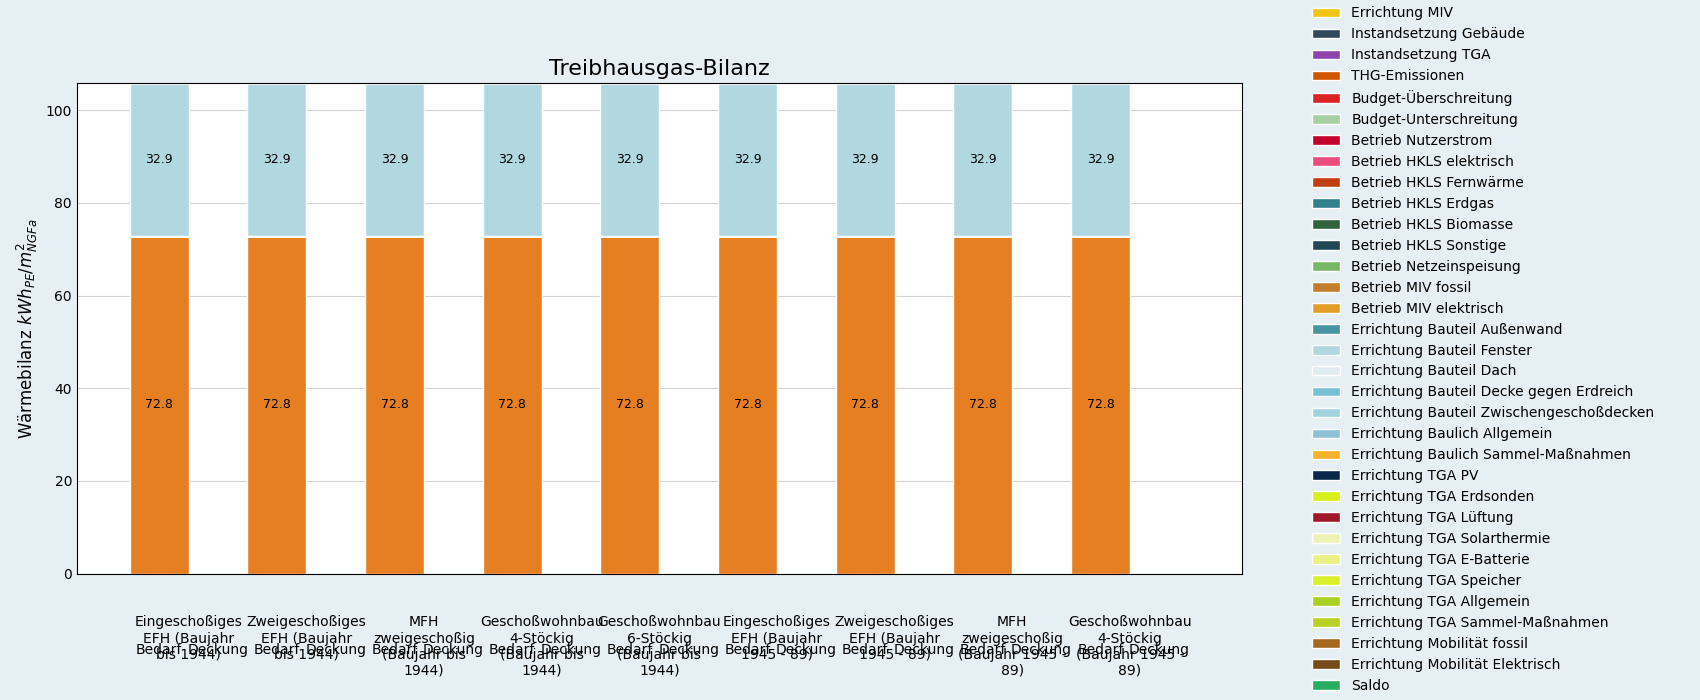

In [68]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import textwrap
import mplcursors

plt.close('all') # Clears previous interactive runs

# 1. Simulate your varnames/scenarios (You likely have a list of these in your real code)
title = "Treibhausgas-Bilanz"
variants_to_display = Variants[:9]
varnames = []
extracted_data = []

for variant in variants_to_display:
    varnames.append(variant)
    extracted_data.append(project[variant].scenarios[0].out.by(domain="embodied_emissions").to_var_dict())
print(len(extracted_data))
# 2. Define the Mapping (Which variables go into which stack)
Emissionen_mapping = {
    "Betrieb Gebäude": ("GWP_oe_lc_building", "#3498db"),
    "Betrieb MIV": ("GWP_oe_lc_mob", "#9b59b6"),
    "Errichtung Gebäude": ("GWP_ee_con_build", "#e67e22"),
    "Errichtung TGA": ("GWP_ee_con_tga", "#1abc9c"),
    "Errichtung MIV": ("GWP_ee_lc_mob", "#f1c40f"),
    "Instandsetzung Gebäude": ("GWP_ee_rep_build", "#34495e"),
    "Instandsetzung TGA": ("GWP_ee_rep_tga", "#8e44ad"),
    "THG-Emissionen": ("GWP_lc_total", "#d35400"),
    "Budget-Überschreitung": ("", "#db2225"),
    "Budget-Unterschreitung": ("", "#a7cfa3"),
    "Betrieb Nutzerstrom": ("GWP_oe_lc_grid_build", "#c0002b"),
    "Betrieb HKLS elektrisch": ("GWP_oe_lc_flex_build", "#eb4b7d"),
    "Betrieb HKLS Fernwärme": ("GWP_oe_lc_district_heating", "#bf3f11"),
    "Betrieb HKLS Erdgas": ("GWP_oe_lc_natural_gas", "#2f818e"),
    "Betrieb HKLS Biomasse": ("GWP_oe_lc_biomass", "#31643c"),
    "Betrieb HKLS Sonstige": ("GWP_oe_lc_other", "#224856"),
    "Betrieb Netzeinspeisung": ("", "#78b965"),
    "Betrieb MIV fossil": ("GWP_oe_lc_mob_fossile", "#c47d2b"),
    "Betrieb MIV elektrisch": ("GWP_oe_lc_mob_ev", "#e49e25"),
    "Errichtung Bauteil Außenwand": ("GWP_ee_lc_walls", "#4795a2"),
    "Errichtung Bauteil Fenster": ("GWP_ee_lc_windows", "#b1d8e1"),
    "Errichtung Bauteil Dach": ("GWP_ee_lc_roof", "#e0ecef"),
    "Errichtung Bauteil Decke gegen Erdreich": ("GWP_ee_lc_ground", "#76c3d5"),
    "Errichtung Bauteil Zwischengeschoßdecken": ("GWP_ee_lc_ceil", "#a2d2df"),
    "Errichtung Baulich Allgemein": ("GWP_ee_lc_general", "#8dc3d5"),
    "Errichtung Baulich Sammel-Maßnahmen": ("GWP_ee_lc_other", "#f6b22b"),
    "Errichtung TGA PV": ("GWP_ee_lc_pv", "#09284b"),
    "Errichtung TGA Erdsonden": ("GWP_ee_lc_boreholes", "#d7ef1a"),
    "Errichtung TGA Lüftung": ("GWP_ee_lc_ventilation", "#9f182c"),
    "Errichtung TGA Solarthermie": ("GWP_ee_lc_solarthermal", "#eff2b5"),
    "Errichtung TGA E-Batterie": ("GWP_ee_lc_battery", "#ebf281"),
    "Errichtung TGA Speicher": ("GWP_ee_lc_storage", "#d9f12b"),
    "Errichtung TGA Allgemein": ("GWP_ee_lc_tga_general", "#a8d124"),
    "Errichtung TGA Sammel-Maßnahmen": ("GWP_ee_lc_tga_other", "#b8d123"),
    "Errichtung Mobilität fossil": ("GWP_ee_mob_fossile", "#a6681d"),
    "Errichtung Mobilität Elektrisch": ("GWP_ee_mob_ev", "#764b18")
}

Saldo_mapping = {
    "Saldo": ("", "#27ae60"),
    "Sockel": ("", "#bdc3c7")
}

Budget_mapping = {
    "THG-Budget": ("", "#4a4a4a")
}

# 4. Setup the Plot
max_chars = 15 # Choose how many characters wide you want the text to be before it breaks to a new line
wrapped_labels = [textwrap.fill(label, width=max_chars) for label in varnames]
x = np.arange(len(varnames)) 
width = 0.5
fig, ax = plt.subplots(num = title, figsize=(len(extracted_data)+8, 7))

all_bars = []

# 5. Plot "Emissionen" (Left bars)
bottom_bedarf = np.zeros(len(varnames))
for label_de, (dict_key, color) in Emissionen_mapping.items():
    # Extract the value for this specific key across all varnames
    # (Note: In your real code, you might need to match dict_key to meta.name)
    values = [data.get(dict_key, 0) for data in extracted_data]
    
    bars = ax.bar(x - width/2, values, width, label=label_de, bottom=bottom_bedarf, color=color, edgecolor="white")
    all_bars.append(bars)
    # Data labels
    for bar in bars:
        height = bar.get_height()
        if height > 10:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f"{height:.1f}", ha="center", va="center", color="black", fontsize=9)
            
    bottom_bedarf += np.array(values)

# 6. Plot "Saldo" (Right bars)
bottom_deckung = np.zeros(len(varnames))
for label_de, (dict_key, color) in Saldo_mapping.items():
    values = [data.get(dict_key, 0) for data in extracted_data]
    
    bars = ax.bar(x + width/2, values, width, label=label_de, bottom=bottom_deckung, color=color, edgecolor="white")
    all_bars.append(bars)
    # Data labels
    for bar in bars:
        height = bar.get_height()
        if height > 10:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f"{height:.1f}", ha="center", va="center", color="black", fontsize=9)
            
    bottom_deckung += np.array(values)

# 6. Plot "Budget" (Right bars)
bottom_deckung = np.zeros(len(varnames))
for label_de, (dict_key, color) in Budget_mapping.items():
    values = [data.get(dict_key, 0) for data in extracted_data]
    
    bars = ax.bar(x + width/2, values, width, label=label_de, bottom=bottom_deckung, color=color, edgecolor="white")
    all_bars.append(bars)
    # Data labels
    for bar in bars:
        height = bar.get_height()
        if height > 10:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2,
                    f"{height:.1f}", ha="center", va="center", color="black", fontsize=9)
            
    bottom_deckung += np.array(values)    

# 7. Add Sub-labels and Formatting
for i in range(len(varnames)):
    ax.text(i - width/2, -15, "Bedarf", ha="center", va="top", fontsize=10)
    ax.text(i + width/2, -15, "Deckung", ha="center", va="top", fontsize=10)

ax.set_ylabel("Wärmebilanz $kWh_{PE}/m^2_{NGFa}$", fontsize = 12)
ax.set_xticks(x)
ax.set_xticklabels(wrapped_labels)
ax.tick_params(axis="x", pad=30) 
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="lightgray", linestyle="-")
ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), frameon=False)
fig.patch.set_facecolor('#e6eff3')
ax.set_title(title, fontsize = 16)

cursor = mplcursors.cursor(all_bars, hover=True)

@cursor.connect("add")
def on_add(sel):
    # 1. Get the category label (e.g., "Fernwärme" or "Heizen")
    category_label = sel.artist.get_label()
    
    # 2. Get the specific rectangle object you are hovering over
    rect = sel.artist[sel.index]
    
    # 3. Get the height (value) of that specific rectangle
    height = rect.get_height()
    
    # 4. Get the x-axis scenario name (using sel.index to map back to varnames)
    variant_name = varnames[sel.index]
    
    # Set the tooltip text dynamically
    sel.annotation.set_text(f"{category_label}: {height:.1f}")
    
    # Style the tooltip box
    sel.annotation.get_bbox_patch().set(alpha=0.9, color='white', edgecolor='gray')

plt.tight_layout()
plt.show()

In [65]:
project["Eingeschoßiges EFH (Baujahr bis 1944)"].scenarios[0].out.by(domain="embodied_emissions").to_var_dict()

{'GWP_ee_walls_fossile': 0,
 'GWP_ee_walls_biogenic': 0,
 'GWP_life_walls': 27,
 'GWP_ee_lc_walls_fossil': 0,
 'GWP_ee_lc_walls_biogenic': 0,
 'GWP_ee_lc_walls': 0,
 'GWP_ee_windows_fossile': 32.8931459378358,
 'GWP_ee_windows_bigenic': 0,
 'GWP_life_windows': 50,
 'GWP_ee_lc_windows_fossile': 32.8931459378358,
 'GWP_ee_lc_windows_biogenic': 0,
 'GWP_ee_lc_windows': 32.8931459378358,
 'GWP_ee_roof_fossile': 0,
 'GWP_ee_roof_biogenic': 0,
 'GWP_life_roof': 27,
 'GWP_ee_lc_roof_fossile': 0,
 'GWP_ee_lc_roof_biogenic': 0,
 'GWP_ee_lc_roof': 0,
 'GWP_ee_ground_fossile': 0,
 'GWP_ee_ground_biogenic': 0,
 'GWP_life_ground': 27,
 'GWP_ee_lc_ground_fossile': 0,
 'GWP_ee_lc_ground_biogenic': 0,
 'GWP_ee_lc_ground': 0,
 'GWP_ee_ceilings_fossile': 0,
 'GWP_ee_ceilings_biogenic': 0,
 'GWP_life_ceilings': 27,
 'GWP_ee_lc_ceilings_fossile': 0,
 'GWP_ee_lc_ceilings_biogenic': 0,
 'GWP_ee_lc_ceil': 0,
 'GWP_ee_general_fossile': 41.5434584707734,
 'GWP_ee_general_bigonenic': -1.58831251522369,
 'GWP_li